In [ ]:
!pip install trl transformers peft accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.4 MB/s eta 0:00:00


In [ ]:
import os
import re
import gc
import json
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional
from collections import defaultdict

import torch
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel



# ============================================================
# 1. Phase 3 配置
# ============================================================
@dataclass
class Phase2Config:
    # 数据集
    dataset_name: str          = "tomg-group-umd/cinepile"
    train_split: str           = "train"
    test_split: str            = "test"

    # 分层抽样（None = 用完整 split）
    max_train_samples: Optional[int] = 30000   # e.g. 从 ~30 万中抽 3 万
    max_test_samples: Optional[int]  = None     # 测试集可截断或用 full

    # hard 样本在分层抽样中的额外倍率（>1 表示更偏向抽 hard）
    hard_oversample_ratio: float     = 1.5   ### Increase hard sample oversampling, training needs stronger representation

    # 模型
    base_model_id: str         = "meta-llama/Llama-3.1-8B-Instruct"

    # 输入长度
    max_scene_length: int      = 1200   ### Change from 1000 to 1200 (allow more scene context)
    max_seq_length: int        = 1536   ### Change from 1024 to 1536 (better reasoning window)

    # 通用训练参数
    num_train_epochs: int      = 4      ### Change from 4 to 5 (LoRA rarely overfits, improves learning)
    per_device_train_batch_size: int = 4   ### Change from 4 to 1 (T4 VRAM stability)
    gradient_accumulation_steps: int = 4  ### Change from 4 to 16 (keep effective batch size ≈16)
    learning_rate: float       = 2e-4
    warmup_ratio: float        = 0.05
    lr_scheduler_type: str     = "cosine"

    bf16: bool                 = True   ### Change to True for A100
    fp16: bool                 = False

    logging_steps: int         = 50

    # checkpoint & 输出
    save_steps: int            = 200
    save_total_limit: int      = 3
    output_base_dir: str       = "./phase2_outputs"
    output_csv: str            = "phase2_results.csv"

    # QLoRA
    lora_r: int                = 64 ### Consider a higher value if the model is struggling to capture the complexity
    lora_alpha: int            = 128
    lora_dropout: float        = 0.00 ### Since we have big example sizes (30000), maybe try 0
    lora_target_modules: List[str] = field(default_factory=lambda: [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ]) ### Recommend all 7 layers, but might also try less

    # Prefix Tuning
    prefix_num_virtual_tokens: int = 20

    # 评估生成长度
    max_new_tokens: int        = 4

    # 类别映射
    category_map: Dict[str, str] = field(default_factory=lambda: {
        "TEMP": "Temporal",
        "CRD":  "Character and",
        "NPA":  "Narrative and",
        "STA":  "Setting and",
        "TH":   "Theme Exploration",
    })


@dataclass
class Phase3Config(Phase2Config):
    # 重用 Phase2Config 里的参数，额外加 Phase3 的一些路径
    phase3_output_dir: str = "./phase3_outputs"
    phase3_pred_file_base: str = "phase3_predictions_base.jsonl"
    phase3_pred_file_qlora: str = "phase3_predictions_qlora.jsonl"


# ============================================================
# 数据加载 & 预处理
# ============================================================
class CinePileDataset:
    LETTERS = ["A", "B", "C", "D", "E"]

    def __init__(self, cfg: Phase2Config):
        self.cfg = cfg
        self.test_data = self._load_all()
        print(f"[Dataset] Test: {len(self.test_data)}")

    @classmethod
    def _answer_text_to_letter(cls, answer_text: str, choices: list) -> str:
        for i, c in enumerate(choices):
            if answer_text.strip() == c.strip():
                return cls.LETTERS[i]
        for i, c in enumerate(choices):
            if answer_text.strip() in c or c.strip() in answer_text:
                return cls.LETTERS[i]
        return "A"

    @staticmethod
    def _normalize_hard_split(raw) -> bool:
        if isinstance(raw, bool):
            return raw
        return str(raw).strip().lower() == "true"

    def _load_split(self, split: str) -> list:
        raw = load_dataset(self.cfg.dataset_name, split=split)
        samples = []
        for ex in raw:
            letter = self._answer_text_to_letter(ex["answer_key"], ex["choices"])
            samples.append({
                "movie_scene":       ex["movie_scene"],
                "question":          ex["question"],
                "choices":           ex["choices"],
                "answer_key":        letter,
                "question_category": ex["question_category"],
                "hard_split":        self._normalize_hard_split(ex["hard_split"]),
            })
        return samples

    def _load_all(self):
        # train_raw = self._load_split(self.cfg.train_split)
        test_raw  = self._load_split(self.cfg.test_split)

        # 训练集分层抽样
        # sampler    = StratifiedSampler(self.cfg)
        # train_data = sampler.sample(train_raw)

        # 测试集截断
        if self.cfg.max_test_samples:
            test_data = test_raw[:self.cfg.max_test_samples]
        else:
            test_data = test_raw

        # return train_data, test_data

        return test_data


# ============================================================
# 2. Prompt 风格与 paraphrase
#    Base style MUST match Phase2 training prompt exactly
# ============================================================
class Phase3PromptBuilder:
    """
    Base 风格必须与 Phase 2 训练 / 推理的 PromptBuilder.build_inference_prompt 完全一致。
    下面直接复制你原来的实现。
    """

    @staticmethod
    def build_base_prompt(sample: dict, max_scene_length: int) -> str:
        # === EXACT COPY of Phase2 PromptBuilder.build_inference_prompt ===
        scene   = sample["movie_scene"][:max_scene_length]
        options = "\n".join(
            f"{chr(65+i)}. {c}" for i, c in enumerate(sample["choices"])
        )
        return (
            "You are watching a movie. Based on the scene description, "
            "answer the multiple choice question.\n\n"
            f"Scene: {scene}\n\n"
            f"Question: {sample['question']}\n\n"
            f"Options:\n{options}\n\n"
            "Answer with only the letter (A, B, C, D, or E):"
        )

    @staticmethod
    def build_prompt(style_name: str, style_prompt: str, sample: dict, max_scene_length: int) -> str:
        """
        style_prompt 是一段“指令部分”（不含 Scene/Question/Options），
        我们把它和 CinePile 内容拼接成完整 prompt。
        对 Base 风格，style_prompt 可以忽略，直接调用 build_base_prompt。
        """
        if style_name == "base":
            # 保证与 Phase 2 完全一致
            return Phase3PromptBuilder.build_base_prompt(sample, max_scene_length)

        scene   = sample["movie_scene"][:max_scene_length]
        options = "\n".join(
            f"{chr(65+i)}. {c}" for i, c in enumerate(sample["choices"])
        )

        # 这里 Strict / CoT 风格保持和 Base 结构类似，只替换指令段
        prompt = (
            f"{style_prompt}\n\n"
            f"Scene: {scene}\n\n"
            f"Question: {sample['question']}\n\n"
            "Think briefly about the scene before choosing the answer.\n\n"
            f"Options:\n{options}\n\n"
            "Answer (A/B/C/D/E):"
        )
        return prompt


# 三种风格 + 每种 3 个 paraphrase
PROMPT_STYLES: Dict[str, List[str]] = {

    "base": [
        "", "", ""
    ],
    "strict": [
        "You are watching a movie. Based on the scene description, answer the multiple choice question. "
        "Respond with only the letter of the correct option (A, B, C, D, or E).",

        "Read the scene description and select the correct option. "
        "Your answer must be a single letter from A to E.",

        "Given the movie scene and question, choose the correct option and reply with only one letter "
        "(A, B, C, D, or E)."
    ],
    "cot": [
        "You are watching a movie. Based on the scene description, think step by step about the question and "
        "options, and then answer with the letter of the correct option (A, B, C, D, or E).",

        "Read the scene description carefully, reason step by step about what is happening, and then give the "
        "letter of the best option from A to E.",

        "Given the movie scene and the question, first think through the relevant details step by step, then "
        "respond with the single letter of the correct choice (A, B, C, D, or E)."
    ],
}

CHOICE_LETTERS = ["A", "B", "C", "D", "E"]


# ============================================================
# 3. 答案解析
# ============================================================
def extract_choice_from_output(text: str) -> str:
    """
    与 Phase2 Evaluator._predict 中逻辑保持一致：寻找 A-E。
    """
    decoded = text.strip().upper()
    match = re.search(r"\b([A-E])\b", decoded)
    if match:
        return match.group(1)
    return None  # 解析失败，后续可以单独统计


# ============================================================
# 4. 通用推理函数：单模型 × 多 prompt
# ============================================================
@torch.inference_mode()
def run_phase3_inference_for_model(
    model,
    tokenizer,
    cfg: Phase3Config,
    test_data: List[dict],
    model_name: str,
    output_path: str,
    max_new_tokens: int = 4,
    batch_size: int = 4,
):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    model.eval()

    all_records = []

    for style_name, paraphrases in PROMPT_STYLES.items():
        for pid, style_prompt in enumerate(paraphrases):
            print(f"[Phase3] Model={model_name} | style={style_name} | paraphrase={pid}")
            for idx in tqdm(range(0, len(test_data)), desc=f"{style_name}-{pid}"):
                sample = test_data[idx]
                prompt = Phase3PromptBuilder.build_prompt(
                    style_name=style_name,
                    style_prompt=style_prompt,
                    sample=sample,
                    max_scene_length=cfg.max_scene_length,
                )

                inputs = tokenizer(
                    prompt,
                    return_tensors="pt",
                    truncation=True,
                    max_length=cfg.max_seq_length,
                )
                inputs = {k: v.to(model.device) for k, v in inputs.items()}

                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id,
                )

                generated = outputs[0][inputs["input_ids"].shape[1]:]
                text = tokenizer.decode(generated, skip_special_tokens=True)
                pred_choice = extract_choice_from_output(text)

                all_records.append({
                    "model": model_name,
                    "index": idx,
                    "style": style_name,
                    "paraphrase_id": pid,
                    "pred": pred_choice,
                    "label": sample["answer_key"],
                    "question_category": sample["question_category"],
                    "hard_split": sample["hard_split"],
                })

    with open(output_path, "w", encoding="utf-8") as f:
        for r in all_records:
            f.write(json.dumps(r) + "\n")

    print(f"[Phase3] Saved predictions → {output_path}")
    return all_records


# ============================================================
# 5. Phase 3 Runner
# ============================================================
class Phase3Runner:
    def __init__(self, cfg: Phase3Config):
        self.cfg = cfg
        self.dataset = CinePileDataset(cfg)  # 复用 Phase2 的加载 + stratified sampling

        # Updated print statement as train_data is no longer loaded
        print(f"[Phase3] Loaded dataset - Test: {len(self.dataset.test_data)}")

    def load_base_model(self):
        print("[Phase3] Loading base model...")
        base_model = AutoModelForCausalLM.from_pretrained(
            self.cfg.base_model_id,
            torch_dtype=torch.bfloat16,
            device_map="auto",
        )
        tokenizer = AutoTokenizer.from_pretrained(self.cfg.base_model_id)
        return base_model, tokenizer

    # Changed to an instance method and arguments updated for correct passing
    def load_qlora_merged_model(self, base_model_id: str, adapter_path:str):

        print("[Merge] Loading base model...")

        base_model = AutoModelForCausalLM.from_pretrained(
            base_model_id,
            torch_dtype=torch.bfloat16,
            device_map="auto",
        )

        tokenizer = AutoTokenizer.from_pretrained(base_model_id)

        print("[Merge] Loading LoRA adapter...")
        model = PeftModel.from_pretrained(base_model, adapter_path)

        print("[Merge] Merging LoRA weights...")
        model = model.merge_and_unload()

        model.eval()

        return model, tokenizer

    # def load_qlora_merged_model(self, adapter_dir: str):
    #     """
    #     直接复用你 Phase2 的 merge 函数。
    #     adapter_dir 应该指向 phase2 qlora_rXX 的输出目录。
    #     """
    #     model, tokenizer = load_merged_model(self.cfg.base_model_id, adapter_dir)
    #     return model, tokenizer

    def run(self, qlora_adapter_dir: str):
        os.makedirs(self.cfg.phase3_output_dir, exist_ok=True)

        # 1. Base model
        # base_model, base_tok = self.load_base_model()
        # base_out_path = os.path.join(self.cfg.phase3_output_dir, self.cfg.phase3_pred_file_base)
        # run_phase3_inference_for_model(
        #     model=base_model,
        #     tokenizer=base_tok,
        #     cfg=self.cfg,
        #     test_data=self.dataset.test_data,
        #     model_name="base",
        #     output_path=base_out_path,
        #     max_new_tokens=self.cfg.max_new_tokens,
        # )
        # del base_model, base_tok
        # gc.collect()
        # torch.cuda.empty_cache()

        # 2. QLoRA merged model
        # Corrected call to load_qlora_merged_model
        qlora_model, qlora_tok = self.load_qlora_merged_model(self.cfg.base_model_id, qlora_adapter_dir)
        qlora_out_path = os.path.join(self.cfg.phase3_output_dir, self.cfg.phase3_pred_file_qlora)
        run_phase3_inference_for_model(
            model=qlora_model,
            tokenizer=qlora_tok,
            cfg=self.cfg,
            test_data=self.dataset.test_data,
            model_name="qlora",
            output_path=qlora_out_path,
            max_new_tokens=self.cfg.max_new_tokens,
        )
        del qlora_model, qlora_tok
        gc.collect()
        torch.cuda.empty_cache()

        print("[Phase3] Inference done. You can now run separate analysis scripts "
              "to compute accuracy, variance, and per-question sensitivity.")


# ============================================================
# 6. main
# ============================================================
if __name__ == "__main__":

    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_DIR = "/content/drive/MyDrive/266_final/phase3"
    os.makedirs(PROJECT_DIR, exist_ok=True)
    print("Project dir:", PROJECT_DIR)

    cfg = Phase3Config(
        base_model_id="meta-llama/Llama-3.1-8B-Instruct",
        # max_train_samples=30000,
        max_test_samples=None,
        # hard_oversample_ratio=1.5,
        # num_train_epochs=4,
        # per_device_train_batch_size=4,
        # gradient_accumulation_steps=4,
        # learning_rate=2e-4,
        output_base_dir=PROJECT_DIR,
        # output_csv=os.path.join(PROJECT_DIR, "phase2_results.csv"),
        phase3_output_dir=os.path.join(PROJECT_DIR, "phase3_outputs"),
    )

    runner = Phase3Runner(cfg)

    # 这里填入 Phase 2 QLoRA 的 adapter 目录，例如：
    qlora_adapter_dir = os.path.join(PROJECT_DIR, "qlora_r64")  # 根据你 Phase2 的 _output_dir 命名

    runner.run(qlora_adapter_dir=qlora_adapter_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/266_final/phase3
[Dataset] Test: 4941
[Phase3] Loaded dataset - Test: 4941
[Merge] Loading base model...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

...

[Phase3] Model=qlora | style=cot | paraphrase=1


cot-1: 100%|██████████| 4941/4941 [12:16<00:00,  6.70it/s]


[Phase3] Model=qlora | style=cot | paraphrase=2


cot-2: 100%|██████████| 4941/4941 [12:26<00:00,  6.62it/s]


[Phase3] Saved predictions → /content/drive/MyDrive/266_final/phase3/phase3_outputs/phase3_predictions_qlora.jsonl
[Phase3] Inference done. You can now run separate analysis scripts to compute accuracy, variance, and per-question sensitivity.


In [ ]:
import json
import os


from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/266_final/phase3"

path = os.path.join(PROJECT_DIR, "phase3_outputs/phase3_predictions_qlora.jsonl")  # adjust if needed

records = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

print(f"Total records: {len(records)}")
print("First 5 records:")
for r in records[:5]:
    print(r)


Mounted at /content/drive
Total records: 44469
First 5 records:
{'model': 'qlora', 'index': 0, 'style': 'base', 'paraphrase_id': 0, 'pred': 'D', 'label': 'E', 'question_category': 'Theme Exploration', 'hard_split': True}
{'model': 'qlora', 'index': 1, 'style': 'base', 'paraphrase_id': 0, 'pred': 'E', 'label': 'E', 'question_category': 'Setting and\nTechnical Analysis', 'hard_split': True}
{'model': 'qlora', 'index': 2, 'style': 'base', 'paraphrase_id': 0, 'pred': 'D', 'label': 'D', 'question_category': 'Setting and\nTechnical Analysis', 'hard_split': True}
{'model': 'qlora', 'index': 3, 'style': 'base', 'paraphrase_id': 0, 'pred': 'B', 'label': 'A', 'question_category': 'Setting and\nTechnical Analysis', 'hard_split': False}
{'model': 'qlora', 'index': 4, 'style': 'base', 'paraphrase_id': 0, 'pred': 'D', 'label': 'D', 'question_category': 'Setting and\nTechnical Analysis', 'hard_split': False}


In [ ]:
import json
import pandas as pd

# Load jsonl
records = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)

# Mark correctness
df["correct"] = df["pred"] == df["label"]

# 1) Overall accuracy (all prompts pooled)
overall_acc = df["correct"].mean()
print(f"Overall accuracy (all prompts pooled): {overall_acc:.3f}")

# 2) Accuracy by question category
cat_stats = df.groupby("question_category")["correct"].mean().reset_index()
cat_stats = cat_stats.rename(columns={"correct": "accuracy"})
print("\nAccuracy by question_category (all prompts pooled):")
print(cat_stats)

# 3) Accuracy by hard_split (True/False)
hard_stats = df.groupby("hard_split")["correct"].mean().reset_index()
hard_stats = hard_stats.rename(columns={"correct": "accuracy"})
print("\nAccuracy by hard_split (all prompts pooled):")
print(hard_stats)


Overall accuracy (all prompts pooled): 0.679

Accuracy by question_category (all prompts pooled):
                      question_category  accuracy
0  Character and\nRelationship Dynamics  0.694391
1          Narrative and\nPlot Analysis  0.697144
2       Setting and\nTechnical Analysis  0.715477
3                              Temporal  0.548450
4                     Theme Exploration  0.645614

Accuracy by hard_split (all prompts pooled):
   hard_split  accuracy
0       False  0.720358
1        True  0.489916


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
import os

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/266_final/phase3"
os.makedirs(PROJECT_DIR, exist_ok=True)
print("Project dir:", PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/266_final/phase3


In [ ]:
df_base = pd.read_json("/content/drive/MyDrive/266_final/phase3/phase3_outputs/phase3_predictions_base.jsonl", lines=True)
df_qlora = pd.read_json("/content/drive/MyDrive/266_final/phase3/phase3_outputs/phase3_predictions_qlora.jsonl", lines=True)
df = pd.concat([df_base, df_qlora])

df["question_category"] = df["question_category"].str.replace("\n", " ")
df["correct"] = (df["pred"] == df["label"])
df = df.rename(columns={"style": "paraphrase_style"})
df.head()

,model,index,paraphrase_style,paraphrase_id,pred,label,question_category,hard_split,correct
0,base,0,base,0,B,E,Theme Exploration,True,False
1,base,1,base,0,E,E,Setting and Technical Analysis,True,True
2,base,2,base,0,B,D,Setting and Technical Analysis,True,False
3,base,3,base,0,B,A,Setting and Technical Analysis,False,False
4,base,4,base,0,B,D,Setting and Technical Analysis,False,False


In [ ]:
cat_map = {
    "Temporal":        "TEMP",
    "Character and":   "CRD",
    "Narrative and":   "NPA",
    "Setting and":     "STA",
    "Theme":           "TH",
}
def normalize_cat(cat_str):
    for kw, abbr in cat_map.items():
        if kw.lower() in str(cat_str).lower():
            return abbr
    return "OTHER"

df["category"] = df["question_category"].apply(normalize_cat)

# 1. Define the grouping columns based on your requirements
# We want accuracy by: model, style, id, category, and difficulty
grouping_cols = [
    'model',
    'paraphrase_style',
    'paraphrase_id',
    'category',
    'hard_split'
]

# 2. Calculate Accuracy
# We group by the columns and calculate the mean of the 'correct' boolean/integer column
accuracy_df = df.groupby(grouping_cols)['correct'].mean().reset_index()

# Rename the result for clarity
accuracy_df.rename(columns={'correct': 'accuracy'}, inplace=True)

# 3. Create a pivot table for a "Publication Ready" view
# This makes it easier to compare models side-by-side across all other variables
styled_table = accuracy_df.pivot_table(
    index=['paraphrase_style', 'paraphrase_id', 'category', 'hard_split'],
    columns='model',
    values='accuracy'
)

# 4. Display the first few rows of the result
print("=== Detailed Accuracy Breakdown ===")
print(styled_table.round(4).head(20))

# Optional: Export to LaTeX for your paper
# print(styled_table.to_latex(index=True, multirow=True, caption="Detailed Accuracy Results"))

=== Detailed Accuracy Breakdown ===
model                                                 base   qlora
paraphrase_style paraphrase_id category hard_split                
base             0             CRD      False       0.6264  0.7160
                                        True        0.4112  0.5132
                               NPA      False       0.5964  0.7292
                                        True        0.4557  0.5823
                               STA      False       0.6616  0.7542
                                        True        0.3738  0.4299
                               TEMP     False       0.4655  0.5857
                                        True        0.2971  0.4268
                               TH       False       0.5396  0.7122
                                        True        0.4510  0.4118
                 1             CRD      False       0.6264  0.7160
                                        True        0.4112  0.5132
                          

In [ ]:


# 1. Define the grouping columns based on your requirements
# We want accuracy by: model, style, id, category, and difficulty
grouping_cols = [
    'model',
    'paraphrase_style',
    'paraphrase_id',
    'category'
]

# 2. Calculate Accuracy
# We group by the columns and calculate the mean of the 'correct' boolean/integer column
accuracy_df = df.groupby(grouping_cols)['correct'].mean().reset_index()

# Rename the result for clarity
accuracy_df.rename(columns={'correct': 'accuracy'}, inplace=True)

# 3. Create a pivot table for a "Publication Ready" view
# This makes it easier to compare models side-by-side across all other variables
styled_table = accuracy_df.pivot_table(
    index=['paraphrase_style', 'paraphrase_id', 'category'],
    columns='model',
    values='accuracy'
)

# 4. Display the first few rows of the result
print("=== Detailed Accuracy Breakdown ===")
print(styled_table.round(4).head(20))

# Optional: Export to LaTeX for your paper
# print(styled_table.to_latex(index=True, multirow=True, caption="Detailed Accuracy Results"))

=== Detailed Accuracy Breakdown ===
model                                      base   qlora
paraphrase_style paraphrase_id category                
base             0             CRD       0.5948  0.6862
                               NPA       0.5724  0.7041
                               STA       0.6214  0.7089
                               TEMP      0.4070  0.5305
                               TH        0.5158  0.6316
                 1             CRD       0.5948  0.6862
                               NPA       0.5724  0.7041
                               STA       0.6214  0.7089
                               TEMP      0.4070  0.5305
                               TH        0.5158  0.6316
                 2             CRD       0.5948  0.6862
                               NPA       0.5724  0.7041
                               STA       0.6214  0.7089
                               TEMP      0.4070  0.5305
                               TH        0.5158  0.6316
cot         

In [ ]:
styled_table

model                                        base     qlora
paraphrase_style paraphrase_id category                    
base             0             CRD       0.594778  0.686170
                               NPA       0.572354  0.704104
                               STA       0.621410  0.708877
                               TEMP      0.406977  0.530523
                               TH        0.515789  0.631579
                 1             CRD       0.594778  0.686170
                               NPA       0.572354  0.704104
                               STA       0.621410  0.708877
                               TEMP      0.406977  0.530523
                               TH        0.515789  0.631579
                 2             CRD       0.594778  0.686170
                               NPA       0.572354  0.704104
                               STA       0.621410  0.708877
                               TEMP      0.406977  0.530523
                               TH        0.515789  0.631579
cot              0             CRD       0.589942  0.698743
                               NPA       0.600432  0.693305
                               STA       0.623368  0.716710
                               TEMP      0.406977  0.558140
                               TH        0.510526  0.663158
                 1             CRD       0.584139  0.701161
                               NPA       0.585313  0.691145
                               STA       0.616841  0.723238
                               TEMP      0.402616  0.561047
                               TH        0.521053  0.657895
                 2             CRD       0.582689  0.697776
                               NPA       0.611231  0.691145
                               STA       0.618146  0.717363
                               TEMP      0.390988  0.552326
                               TH        0.515789  0.652632
strict           0             CRD       0.588491  0.700677
                               NPA       0.600432  0.693305
                               STA       0.625979  0.717363
                               TEMP      0.395349  0.561047
                               TH        0.521053  0.652632
                 1             CRD       0.586074  0.697776
                               NPA       0.587473  0.699784
                               STA       0.625326  0.718016
                               TEMP      0.390988  0.559593
                               TH        0.521053  0.652632
                 2             CRD       0.576886  0.694874
                               NPA       0.587473  0.693305
                               STA       0.619452  0.719974
                               TEMP      0.385174  0.552326
                               TH        0.510526  0.636842

In [ ]:
styled_table.to_csv("/content/drive/MyDrive/266_final/phase3/analysis/pivot_table.csv")

In [ ]:
import json, pandas as pd, numpy as np
from collections import defaultdict

# Load both files
# records = []
# for path in ["phase3_outputs/phase3_predictions_base.jsonl",
#              "phase3_outputs/phase3_predictions_qlora.jsonl"]:
#     with open(path, "r") as f:
#         for line in f:
#             records.append(json.loads(line))

# df = pd.DataFrame(records)
# df["correct"] = df["pred"] == df["label"]

# Normalize category to short abbreviation
cat_map = {
    "Temporal":        "TEMP",
    "Character and":   "CRD",
    "Narrative and":   "NPA",
    "Setting and":     "STA",
    "Theme":           "TH",
}
def normalize_cat(cat_str):
    for kw, abbr in cat_map.items():
        if kw.lower() in str(cat_str).lower():
            return abbr
    return "OTHER"

df["category"] = df["question_category"].apply(normalize_cat)

# ── Analysis 1: Accuracy by model × category (pooled over all prompts) ────────
cat_acc = (df.groupby(["model","category"])["correct"]
             .mean()
             .reset_index()
             .rename(columns={"correct":"accuracy"}))
print("=== Accuracy by Model × Category (all prompts pooled) ===")
print(cat_acc.pivot(index="category", columns="model", values="accuracy").round(4))

# ── Analysis 2: Accuracy by model × hard_split (pooled) ─────────────────────
hard_acc = (df.groupby(["model","hard_split"])["correct"]
              .mean()
              .reset_index()
              .rename(columns={"correct":"accuracy"}))
print("\n=== Accuracy by Model × Hard Split ===")
print(hard_acc.pivot(index="hard_split", columns="model", values="accuracy").round(4))

# ── Analysis 3: Sensitivity (std) by category × model ────────────────────────
# For each (model, category, question index), get accuracy per paraphrase
# then std across paraphrases
per_q = (df.groupby(["model","category","index","paraphrase_style"])
           .apply(lambda g: g["correct"].mean())
           .reset_index(name="acc_per_style"))

sens = (per_q.groupby(["model","category","index"])["acc_per_style"]
              .std()
              .reset_index(name="sensitivity"))

cat_sens = (sens.groupby(["model","category"])["sensitivity"]
                .mean()
                .reset_index())
print("\n=== Mean Sensitivity (std) by Model × Category ===")
print(cat_sens.pivot(index="category", columns="model", values="sensitivity").round(4))

# ── Analysis 4: Sensitivity by hard_split × model ────────────────────────────
df2 = df.merge(df[["model","index","hard_split"]].drop_duplicates(),
               on=["model","index","hard_split"])

hard_sens_per_q = (df.groupby(["model","hard_split","index","paraphrase_style"])
                     .apply(lambda g: g["correct"].mean())
                     .reset_index(name="acc"))
hard_sens = (hard_sens_per_q.groupby(["model","hard_split","index"])["acc"]
                              .std()
                              .reset_index(name="sensitivity"))
hard_sens_agg = (hard_sens.groupby(["model","hard_split"])["sensitivity"]
                            .mean()
                            .reset_index())
print("\n=== Mean Sensitivity by Model × Hard Split ===")
print(hard_sens_agg.pivot(index="hard_split", columns="model",
                           values="sensitivity").round(4))

# ── Analysis 5: Style effect by category (where does CoT/Strict help most?) ──
style_cat = (df.groupby(["model","paraphrase_style","category"])["correct"]
               .mean()
               .reset_index()
               .rename(columns={"correct":"accuracy"}))

# Focus on QLoRA only
qlora_style_cat = style_cat[style_cat["model"]=="qlora"].pivot(
    index="category", columns="paraphrase_style", values="accuracy").round(4)
print("\n=== QLoRA Accuracy by Category × Style ===")
print(qlora_style_cat)

=== Accuracy by Model × Category (all prompts pooled) ===
model       base   qlora
category                
CRD       0.5881  0.6944
NPA       0.5877  0.6971
STA       0.6215  0.7155
TEMP      0.3992  0.5484
TH        0.5164  0.6456

=== Accuracy by Model × Hard Split ===
model         base   qlora
hard_split                
False       0.6109  0.7204
True        0.3794  0.4899


/tmp/ipykernel_1738/1434528410.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["correct"].mean())



=== Mean Sensitivity (std) by Model × Category ===
model       base   qlora
category                
CRD       0.1061  0.0536
NPA       0.0774  0.0573
STA       0.0916  0.0523
TEMP      0.1303  0.0848
TH        0.1367  0.0504

=== Mean Sensitivity by Model × Hard Split ===
model         base   qlora
hard_split                
False       0.1013  0.0531
True        0.1132  0.0793

=== QLoRA Accuracy by Category × Style ===
paraphrase_style    base     cot  strict
category                                
CRD               0.6862  0.6992  0.6978
NPA               0.7041  0.6919  0.6955
STA               0.7089  0.7191  0.7185
TEMP              0.5305  0.5572  0.5577
TH                0.6316  0.6579  0.6474


/tmp/ipykernel_1738/1434528410.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["correct"].mean())


**Finding 1 — TEMP is the hardest and most benefited category.**

Base LLM scores near-chance on TEMP (39.9%), and QLoRA produces the largest absolute gain here (+14.9 pp). Temporal reasoning is the primary weakness of the base model on CinePile and the primary beneficiary of task-specific fine-tuning.

**Finding 2 — TH and TEMP are most sensitive to instruction wording.**

For the Base LLM, TH and TEMP show sensitivity scores more than 1.5× higher than NPA, suggesting these reasoning types are more dependent on exactly how the task is framed. QLoRA reduces this sensitivity most dramatically on TH and moderately on TEMP.

**Finding 3 — Hard questions remain challenging even after QLoRA.**

Despite an 11.1 pp improvement, QLoRA Hard accuracy (49.0%) remains 23 pp below Non-Hard accuracy (72.0%), indicating a persistent difficulty gap that neither general fine-tuning nor prompt engineering fully closes.


**Finding 4 — CoT and Strict-Letter selectively help TEMP and TH, but can hurt NPA.**

Prompt style should be chosen per reasoning type rather than applied uniformly. For deployment, CoT or Strict-Letter should be preferred for temporal and theme questions, while Base-style prompt is safer for narrative and setting questions.

In [ ]:
%matplotlib inline
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
import os

os.makedirs("output", exist_ok=True)

# ── Palette & global style ─────────────────────────────────────────────────────
C1="#c8e1b5"; C2="#80c5b6"; C3="#3db2c0"; C4="#2a80ba"; C5="#24428e"
MODEL_BASE=C3; MODEL_QLORA=C5; COT_COLOR=C1; STRICT_COLOR=C2

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "font.size":        12,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   12,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "axes.grid.axis":   "y",
    "grid.color":       "#e5e5e5",
    "grid.linewidth":   0.8,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  11,
    "legend.frameon":   False,
    "figure.dpi":       150,
    "savefig.dpi":      200,
    "savefig.bbox":     "tight",
})

# ── Data ──────────────────────────────────────────────────────────────────────
cat_order = ["TEMP","CRD","NPA","STA","TH"]

acc_cat = pd.DataFrame({
    "category": cat_order,
    "Base LLM": [0.3992, 0.5881, 0.5877, 0.6215, 0.5164],
    "QLoRA":    [0.5484, 0.6944, 0.6971, 0.7155, 0.6456],
})
acc_cat["delta"] = acc_cat["QLoRA"] - acc_cat["Base LLM"]

hard_acc = pd.DataFrame({
    "split":    ["Non-Hard","Hard"],
    "Base LLM": [0.6109, 0.3794],
    "QLoRA":    [0.7204, 0.4899],
})
hard_acc["delta"] = hard_acc["QLoRA"] - hard_acc["Base LLM"]

sens_cat = pd.DataFrame({
    "category": cat_order,
    "Base LLM": [0.1303, 0.1061, 0.0774, 0.0916, 0.1367],
    "QLoRA":    [0.0848, 0.0536, 0.0573, 0.0523, 0.0504],
})

qlora_style = pd.DataFrame({
    "category": cat_order,
    "Base":     [0.5305, 0.6862, 0.7041, 0.7089, 0.6316],
    "CoT":      [0.5572, 0.6992, 0.6919, 0.7191, 0.6579],
    "Strict":   [0.5577, 0.6978, 0.6955, 0.7185, 0.6474],
})
qlora_style["cot_d"]    = qlora_style["CoT"]    - qlora_style["Base"]
qlora_style["strict_d"] = qlora_style["Strict"] - qlora_style["Base"]

x = np.arange(len(cat_order))
w = 0.35


# ══════════════════════════════════════════════════════════════════════════════
# Fig 4 – Accuracy by Question Category
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))

b1 = ax.bar(x - w/2, acc_cat["Base LLM"], width=w, color=MODEL_BASE,
            label="Base LLM", zorder=3)
b2 = ax.bar(x + w/2, acc_cat["QLoRA"],    width=w, color=MODEL_QLORA,
            label="QLoRA", zorder=3)

# value labels
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=10)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=10)

# delta annotations
for i, row in acc_cat.iterrows():
    ax.text(x[i], row["QLoRA"]+0.065, f"+{row['delta']:.1%}",
            ha="center", va="bottom", fontsize=9.5, color="#555555",
            fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(cat_order)
ax.set_ylim(0, 0.88)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:.0%}"))
ax.set_xlabel("Question Category"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Question Category: Base LLM vs. QLoRA")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig("output/fig4_cat_accuracy.png")
plt.close()
print("Fig 4 saved.")

# ══════════════════════════════════════════════════════════════════════════════
# Fig 5 – Accuracy by Difficulty Split
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(5.5, 5))
xh = np.arange(2)

b1 = ax.bar(xh - w/2, hard_acc["Base LLM"], width=w, color=MODEL_BASE, label="Base LLM", zorder=3)
b2 = ax.bar(xh + w/2, hard_acc["QLoRA"],    width=w, color=MODEL_QLORA, label="QLoRA",    zorder=3)
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=11)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
            f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=11)
for i, row in hard_acc.iterrows():
    ax.text(xh[i], row["QLoRA"]+0.065, f"+{row['delta']:.1%}",
            ha="center", va="bottom", fontsize=10.5, color="#555555", fontweight="bold")

ax.set_xticks(xh); ax.set_xticklabels(hard_acc["split"])
ax.set_ylim(0, 0.88)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:.0%}"))
ax.set_xlabel("Difficulty Split"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Difficulty Split: Base LLM vs. QLoRA")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig("output/fig5_hard_accuracy.png")
plt.close()
print("Fig 5 saved.")

# ══════════════════════════════════════════════════════════════════════════════
# Fig 6 – Sensitivity Heatmap
# ══════════════════════════════════════════════════════════════════════════════
heat_data = pd.DataFrame({
    "Base LLM": list(sens_cat["Base LLM"]),
    "QLoRA":    list(sens_cat["QLoRA"]),
}, index=cat_order).T

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("custom",
    ["#f0f7ff", C1, C3, C4, C5], N=256)

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(heat_data, annot=True, fmt=".4f", cmap=cmap,
            vmin=0, vmax=0.14, linewidths=0.5, linecolor="#dddddd",
            annot_kws={"size":12, "weight":"bold"},
            cbar_kws={"label":"Std", "shrink":0.85},
            ax=ax)
ax.set_title("Instruction Sensitivity by Category (Std across 9 Prompts)", pad=10)
ax.set_xlabel("Question Category"); ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
# Turn off seaborn grid (heatmap handles its own lines)
ax.grid(False)
fig.tight_layout()
fig.savefig("output/fig6_sensitivity_cat.png")
plt.close()
print("Fig 6 saved.")

# ══════════════════════════════════════════════════════════════════════════════
# Fig 7 – QLoRA Style Delta per Category
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))

b1 = ax.bar(x - w/2, qlora_style["cot_d"],    width=w, color=COT_COLOR,
            label="CoT − Base", zorder=3)
b2 = ax.bar(x + w/2, qlora_style["strict_d"], width=w, color=STRICT_COLOR,
            label="Strict-Letter − Base", zorder=3)

for bar in b1:
    yval = bar.get_height()
    ypos = yval + 0.001 if yval >= 0 else yval - 0.003
    va   = "bottom" if yval >= 0 else "top"
    ax.text(bar.get_x()+bar.get_width()/2, ypos,
            f"{yval:+.1%}", ha="center", va=va, fontsize=10)
for bar in b2:
    yval = bar.get_height()
    ypos = yval + 0.001 if yval >= 0 else yval - 0.003
    va   = "bottom" if yval >= 0 else "top"
    ax.text(bar.get_x()+bar.get_width()/2, ypos,
            f"{yval:+.1%}", ha="center", va=va, fontsize=10)

ax.axhline(0, color="#888888", linewidth=1.2, linestyle="--", zorder=2)
ax.set_xticks(x); ax.set_xticklabels(cat_order)
ax.set_ylim(-0.032, 0.050)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:+.1%}"))
ax.set_xlabel("Question Category")
ax.set_ylabel("Δ Accuracy vs. Base Prompt")
ax.set_title("QLoRA Prompt Style Effect per Category (Δ vs. Base Prompt)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig("output/fig7_style_delta.png")
plt.close()
print("Fig 7 saved.")

# ══════════════════════════════════════════════════════════════════════════════
# Fig 3b – Combined Sensitivity (categories + hard split)
# ══════════════════════════════════════════════════════════════════════════════
x_all   = cat_order + ["Non-Hard","Hard"]
base_s  = list(sens_cat["Base LLM"]) + [0.1013, 0.1132]
qlora_s = list(sens_cat["QLoRA"])    + [0.0531, 0.0793]
xa      = np.arange(len(x_all))

fig, ax = plt.subplots(figsize=(9.5, 5))
b1 = ax.bar(xa - w/2, base_s,  width=w, color=MODEL_BASE,  label="Base LLM", zorder=3)
b2 = ax.bar(xa + w/2, qlora_s, width=w, color=MODEL_QLORA, label="QLoRA",    zorder=3)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

# Divider between categories and difficulty
ax.axvline(x=4.5, color="#aaaaaa", linestyle="--", linewidth=1.2, zorder=2)
ax.text(1.8, 0.152, "By Category",   ha="center", fontsize=10.5, color="#555555")
ax.text(5.5, 0.152, "By Difficulty", ha="center", fontsize=10.5, color="#555555")

ax.set_xticks(xa); ax.set_xticklabels(x_all)
ax.set_ylim(0, 0.17)
ax.set_xlabel("Group"); ax.set_ylabel("Mean Sensitivity (Std)")
ax.set_title("Instruction Sensitivity: Categories & Difficulty Splits")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig("output/fig3b_sensitivity_all.png")
plt.close()
print("Fig 3b saved.")

Fig 4 saved.
Fig 5 saved.
Fig 6 saved.
Fig 7 saved.
Fig 3b saved.


# **Finding 1:**
QLoRA outperforms the Base LLM across all five categories, but the gain is highly non-uniform. The largest absolute improvement is on TEMP (+14.9 pp), where the Base LLM scores only 39.9% — barely above chance for a 5-way task. QLoRA raises this to 54.8%, suggesting that fine-tuning on CinePile directly targets the temporal reasoning deficit that is most prominent in the base model. Gains on CRD, NPA, STA, and TH are more modest (+6–9 pp), indicating these categories benefit from general QLoRA alignment but are already reasonably accessible to the base model.

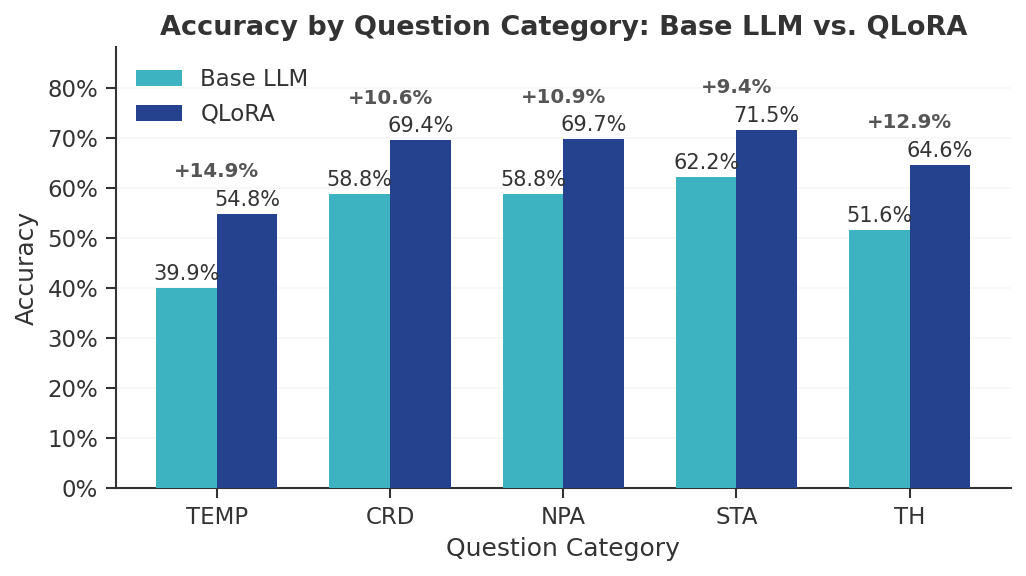

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

b1 = ax.bar(x - w/2, acc_cat["Base LLM"], width=w, color=MODEL_BASE, label="Base LLM", zorder=3)
b2 = ax.bar(x + w/2, acc_cat["QLoRA"],    width=w, color=MODEL_QLORA, label="QLoRA", zorder=3)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008, f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=10)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008, f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=10)

for i, row in acc_cat.iterrows():
    ax.text(x[i], row["QLoRA"]+0.065, f"+{row['delta']:.1%}", ha="center", va="bottom", fontsize=9.5, color="#555555", fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(cat_order)
ax.set_ylim(0, 0.88)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:.0%}"))
ax.set_xlabel("Question Category"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Question Category: Base LLM vs. QLoRA")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

/tmp/ipykernel_1738/1294930349.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["20%", "40%", "60%", "80%"], color="grey", fontsize=9)


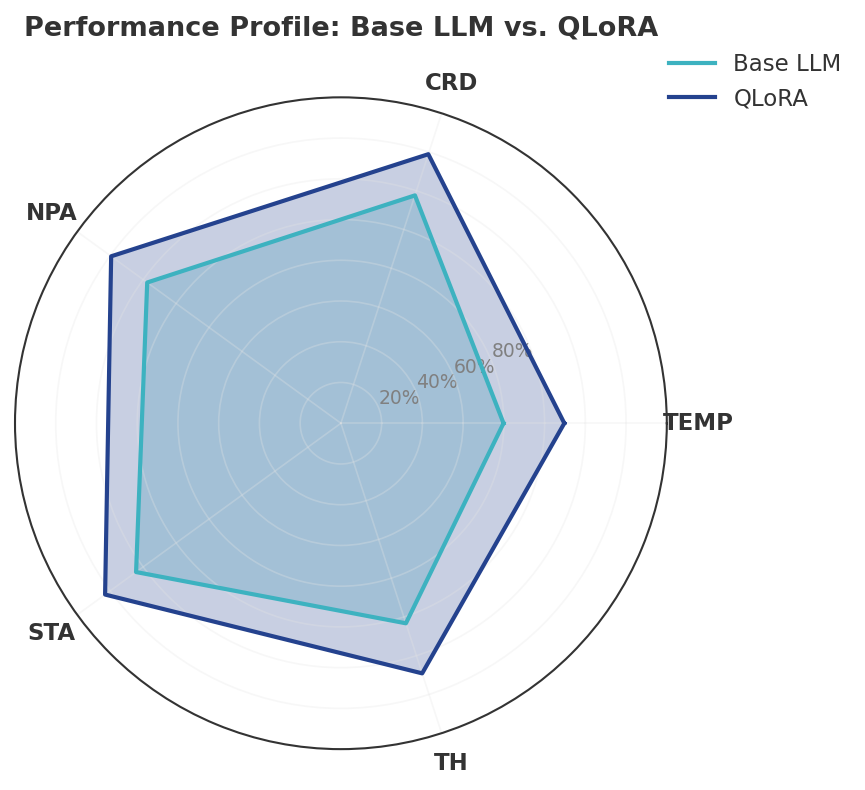

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data Preparation ---
categories = ["TEMP", "CRD", "NPA", "STA", "TH"]
base_llm = [0.3992, 0.5881, 0.5877, 0.6215, 0.5164]
qlora =    [0.5484, 0.6944, 0.6971, 0.7155, 0.6456]

# Number of variables
num_vars = len(categories)

# Compute angle for each bar
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is a circle, so we need to "complete the loop"
# by appending the start value to the end.
base_llm += base_llm[:1]
qlora += qlora[:1]
angles += angles[:1]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Draw the outline and fill for Base LLM
ax.plot(angles, base_llm, color=MODEL_BASE, linewidth=2, label="Base LLM")
ax.fill(angles, base_llm, color=MODEL_BASE, alpha=0.25)

# Draw the outline and fill for QLoRA
ax.plot(angles, qlora, color=MODEL_QLORA, linewidth=2, label="QLoRA")
ax.fill(angles, qlora, color=MODEL_QLORA, alpha=0.25)

# Fix axis to go from 0 to 100% (or 0.8 to keep it tight)
ax.set_ylim(0, 0.8)

# Set category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')

# Add percentage labels to the radial grid
ax.set_yticklabels(["20%", "40%", "60%", "80%"], color="grey", fontsize=9)

# Polish
ax.set_title("Performance Profile: Base LLM vs. QLoRA", pad=30, fontsize=13, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=False)

plt.tight_layout()
plt.show()

# **Finding 2:**
The Hard split reveals the steepest challenge: the Base LLM scores only 37.9% on Hard questions (below random chance level of 20% but well below the Non-Hard level of 61.1%), while QLoRA raises Hard accuracy to 49.0% (+11.1 pp). Crucially, the Non-Hard gain is smaller (+10.9 pp), meaning QLoRA does not simply shift all questions up uniformly — it disproportionately helps on structurally harder reasoning. However, the Hard-vs-Non-Hard performance gap remains large even for QLoRA (72.0% vs 49.0%), highlighting that Hard questions remain an open challenge even after fine-tuning.

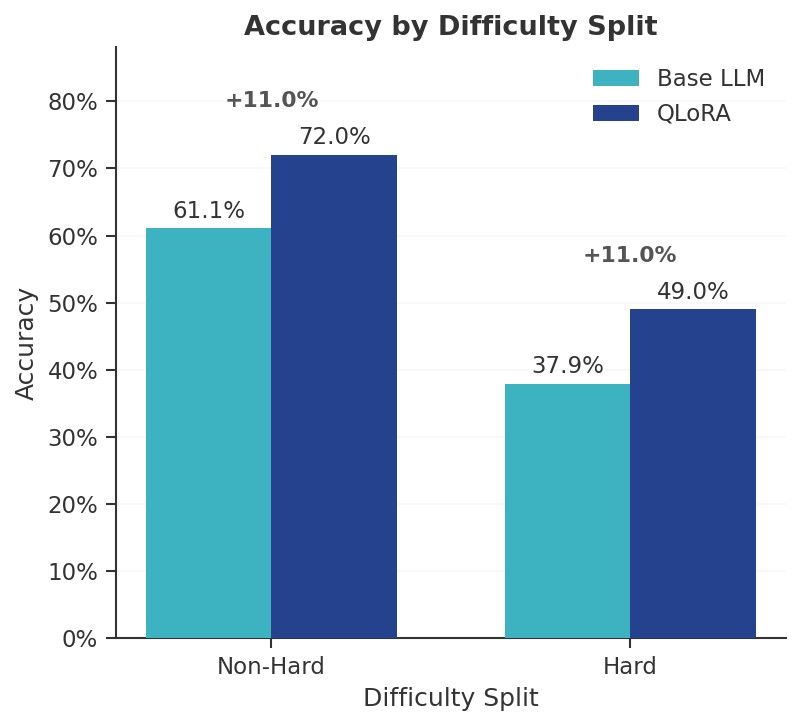

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5))
xh = np.arange(2)

b1 = ax.bar(xh - w/2, hard_acc["Base LLM"], width=w, color=MODEL_BASE, label="Base LLM", zorder=3)
b2 = ax.bar(xh + w/2, hard_acc["QLoRA"],    width=w, color=MODEL_QLORA, label="QLoRA", zorder=3)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008, f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=11)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008, f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=11)
for i, row in hard_acc.iterrows():
    ax.text(xh[i], row["QLoRA"]+0.065, f"+{row['delta']:.1%}", ha="center", va="bottom", fontsize=10.5, color="#555555", fontweight="bold")

ax.set_xticks(xh); ax.set_xticklabels(hard_acc["split"])
ax.set_ylim(0, 0.88)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:.0%}"))
ax.set_xlabel("Difficulty Split"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Difficulty Split")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

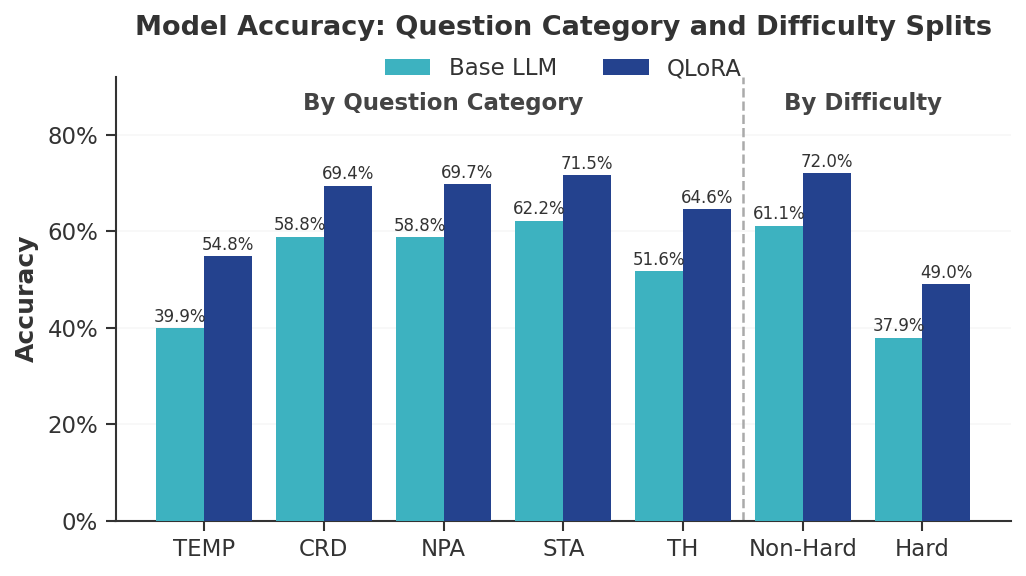

In [ ]:
# 1. Prepare combined data
all_labels = list(acc_cat["category"]) + list(hard_acc["split"])
all_base   = list(acc_cat["Base LLM"]) + list(hard_acc["Base LLM"])
all_qlora  = list(acc_cat["QLoRA"])    + list(hard_acc["QLoRA"])
all_delta  = list(acc_cat["delta"])    + list(hard_acc["delta"])

xa = np.arange(len(all_labels))
w = 0.4  # Slightly wider bars for better cluster grouping

fig, ax = plt.subplots(figsize=(7, 4))

# 2. Draw bars
b1 = ax.bar(xa - w/2, all_base,  width=w, color=MODEL_BASE,  label="Base LLM", zorder=3)
b2 = ax.bar(xa + w/2, all_qlora, width=w, color=MODEL_QLORA, label="QLoRA",    zorder=3)

# 3. Add value labels (individual accuracy)
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.1%}",
                ha="center", va="bottom", fontsize=8)

# # 4. Add delta annotations (improvement)
# for i, delta in enumerate(all_delta):
#     ax.text(xa[i], all_qlora[i] + 0.06,
#             f"Δ +{delta:.1%}",
#             ha="center", va="bottom", fontsize=9.5,
#             color="#555555", fontweight="bold")

# 5. Visual divider and category labels
ax.axvline(x=4.5, color="#aaaaaa", linestyle="--", linewidth=1.2, zorder=2)
ax.text(2.0, 0.85, "By Question Category", ha="center", fontsize=11, color="#444444", fontweight="bold")
ax.text(5.5, 0.85, "By Difficulty", ha="center", fontsize=11, color="#444444", fontweight="bold")

# 6. Final Formatting
ax.set_xticks(xa)
ax.set_xticklabels(all_labels)
ax.set_ylim(0, 0.92) # Extra head room for the Delta labels
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

ax.set_ylabel("Accuracy", fontweight="bold")
ax.set_title("Model Accuracy: Question Category and Difficulty Splits", pad=20)

# Move legend to top center to save horizontal space
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.09), ncol=2, frameon=False)

fig.tight_layout()
plt.show()

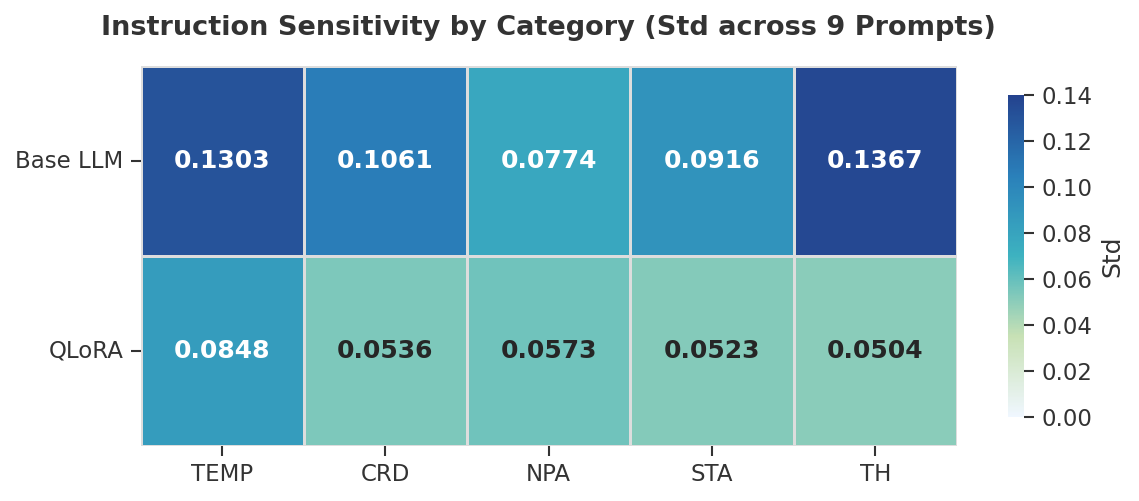

# **Finding 4:**

For QLoRA, CoT and Strict-Letter styles have selective, not uniform, effects across categories:

TEMP benefits most: CoT gives +2.7 pp and Strict-Letter gives +2.7 pp over the Base prompt — the only category where both styles consistently help. This confirms that temporal reasoning specifically benefits from either more explicit step-by-step reasoning or cleaner answer formatting.

TH also benefits: CoT gives +2.6 pp, suggesting theme-level reasoning also responds positively to step-by-step prompting.

NPA shows a slight CoT penalty (−1.2 pp): narrative plot-level questions may actually be hurt by over-instructing the model to "think step by step," possibly because these questions are more straightforward and CoT introduces noise.

STA and CRD are nearly neutral: both styles stay within ±1.3 pp of Base, indicating these category answers are stable regardless of instruction style.

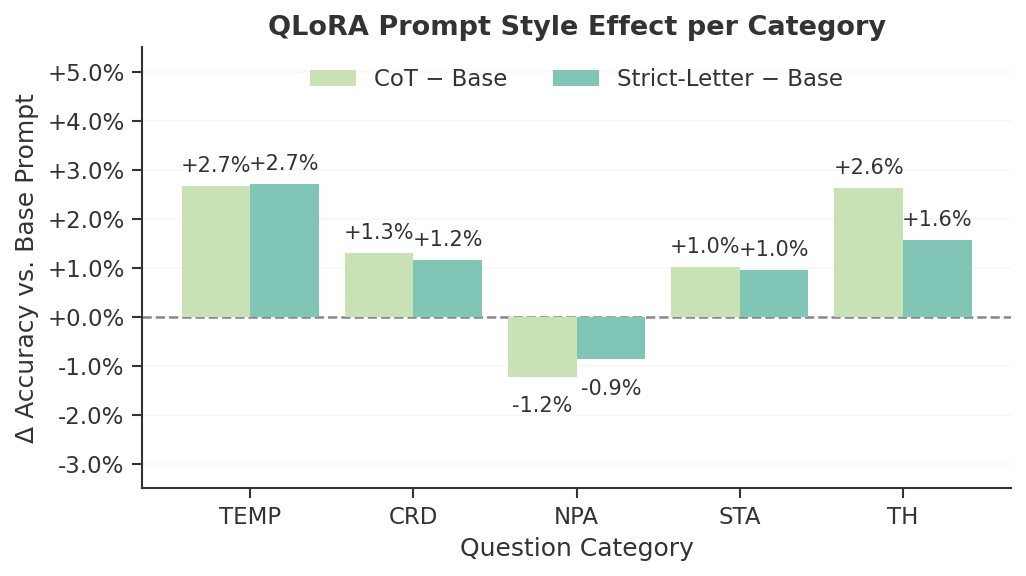

In [ ]:
# Change this line
w = 0.42  # Increased from 0.35 to make clusters "fatter" and gaps narrower

fig, ax = plt.subplots(figsize=(7, 4))

# The x - w/2 and x + w/2 logic ensures they touch or stay close
# regardless of how wide they are.
b1 = ax.bar(x - w/2, qlora_style["cot_d"], width=w, color=COT_COLOR,
            label="CoT − Base", zorder=3)
b2 = ax.bar(x + w/2, qlora_style["strict_d"], width=w, color=STRICT_COLOR,
            label="Strict-Letter − Base", zorder=3)

for bars in [b1, b2]:
    for bar in bars:
        yval = bar.get_height()
        ypos = yval + 0.002 if yval >= 0 else yval - 0.004
        va = "bottom" if yval >= 0 else "top"
        ax.text(bar.get_x()+bar.get_width()/2, ypos, f"{yval:+.1%}", ha="center", va=va, fontsize=10)

ax.axhline(0, color="#888888", linewidth=1.2, linestyle="--", zorder=2)
ax.set_xticks(x); ax.set_xticklabels(cat_order)
ax.set_ylim(-0.035, 0.055)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:+.1%}"))
ax.set_xlabel("Question Category"); ax.set_ylabel("Δ Accuracy vs. Base Prompt")
ax.set_title("QLoRA Prompt Style Effect per Category")
ax.legend(loc="upper center", ncol=2)
fig.tight_layout()
plt.show()

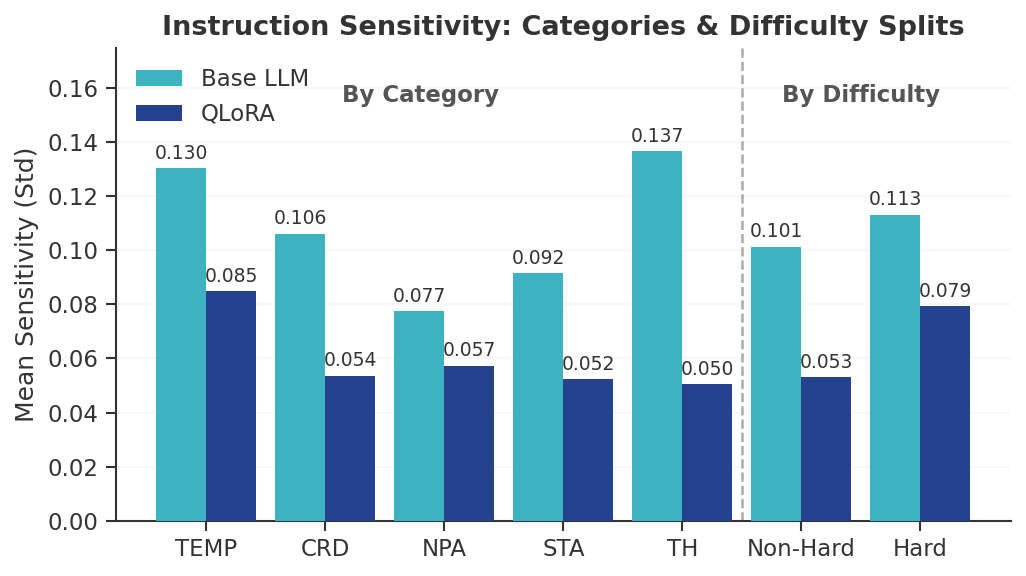

In [ ]:
x_all = cat_order + ["Non-Hard","Hard"]
base_s = list(sens_cat["Base LLM"]) + [0.1013, 0.1132]
qlora_s = list(sens_cat["QLoRA"])  + [0.0531, 0.0793]
xa = np.arange(len(x_all))

fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(xa - w/2, base_s,  width=w, color=MODEL_BASE,  label="Base LLM", zorder=3)
b2 = ax.bar(xa + w/2, qlora_s, width=w, color=MODEL_QLORA, label="QLoRA",    zorder=3)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.axvline(x=4.5, color="#aaaaaa", linestyle="--", linewidth=1.2, zorder=2)
ax.text(1.8, 0.155, "By Category",   ha="center", fontsize=11, color="#555555", fontweight="bold")
ax.text(5.5, 0.155, "By Difficulty", ha="center", fontsize=11, color="#555555", fontweight="bold")

ax.set_xticks(xa); ax.set_xticklabels(x_all)
ax.set_ylim(0, 0.175)
ax.set_ylabel("Mean Sensitivity (Std)")
ax.set_title("Instruction Sensitivity: Categories & Difficulty Splits")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

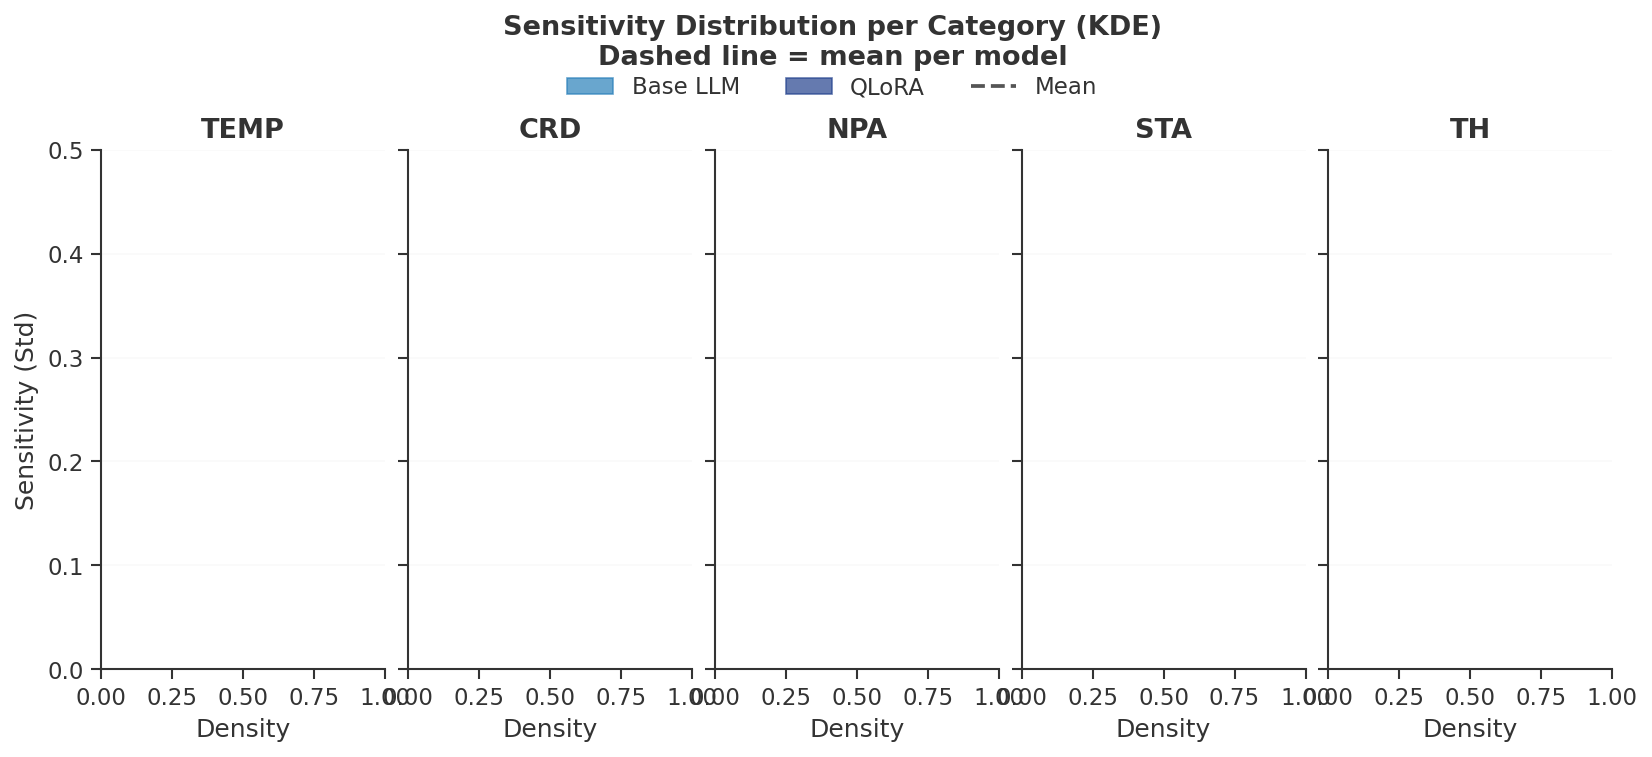

In [ ]:
# Per-question sensitivity = std across all 9 prompts
def norm_cat(c):
    c = str(c)
    for kw, ab in [("Temporal", "TEMP"),
                   ("Character", "CRD"),
                   ("Narrative", "NPA"),
                   ("Setting",   "STA"),
                   ("Theme",     "TH")]:
        if kw.lower() in c.lower():
            return ab
    return "OTHER"

sens = df.groupby(["model","index"])["correct"].std().reset_index(name="sensitivity")
meta = df[["index","model","question_category"]].drop_duplicates()
sens = sens.merge(meta, on=["index","model"])
sens["category"] = sens["question_category"].apply(norm_cat)

# Then paste Option A or B plotting code below

# ── Palette ────────────────────────────────────────────────────────────────────
C1="#c8e1b5"; C2="#80c5b6"; C3="#3db2c0"; C4="#2a80ba"; C5="#24428e"
FONT = "DejaVu Sans"
MODEL_BASE  = C4
MODEL_QLORA = C5

plt.rcParams.update({
    "font.family": FONT, "font.size": 12,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": "#e8e8e8", "grid.linewidth": 0.8,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "legend.fontsize": 11, "legend.frameon": False,
    "figure.dpi": 150, "savefig.dpi": 200, "savefig.bbox": "tight",
})

cat_order = ["TEMP","CRD","NPA","STA","TH"]
palette   = {"Base LLM": MODEL_BASE, "QLoRA": MODEL_QLORA}

# ══════════════════════════════════════════════════════════════════════════════
# Option C – Ridgeline / KDE facet (creative, publishable)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 5, figsize=(13, 4.5), sharey=False, sharex=True)
fig.subplots_adjust(wspace=0.08)

for i, cat in enumerate(cat_order):
    ax = axes[i]
    for model, color in [("Base LLM", MODEL_BASE), ("QLoRA", MODEL_QLORA)]:
        d = sens[(sens["category"]==cat)&(sens["model"]==model)]["sensitivity"]
        sns.kdeplot(y=d, ax=ax, fill=True, color=color, alpha=0.45,
                    linewidth=1.5, bw_adjust=1.2, cut=0)
        m = d.mean()
        ax.axhline(m, color=color, linewidth=1.8, linestyle="--", alpha=0.9)

    ax.set_title(cat, fontweight="bold", fontsize=13)
    ax.set_xlabel("Density")
    ax.set_xlim(0, None)
    ax.set_ylim(0, 0.50)
    if i == 0:
        ax.set_ylabel("Sensitivity (Std)")
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#eeeeee", linewidth=0.8)

# Legend
handles = [
    mpatches.Patch(color=MODEL_BASE,  alpha=0.7, label="Base LLM"),
    mpatches.Patch(color=MODEL_QLORA, alpha=0.7, label="QLoRA"),
    plt.Line2D([0],[0], color="#555555", linewidth=1.8,
               linestyle="--", label="Mean"),
]
fig.legend(handles=handles, loc="upper center", ncol=3,
           bbox_to_anchor=(0.5, 1.02), fontsize=11)
fig.suptitle("Sensitivity Distribution per Category (KDE)\n"
             "Dashed line = mean per model", y=1.08, fontsize=13, fontweight="bold")
plt.show()

In [ ]:
sens

,model,index,sensitivity,question_category,category
0,base,0,0.000000,Theme Exploration,TH
1,base,1,0.000000,Setting and Technical Analysis,STA
2,base,2,0.000000,Setting and Technical Analysis,STA
3,base,3,0.527046,Setting and Technical Analysis,STA
4,base,4,0.000000,Setting and Technical Analysis,STA
...,...,...,...,...,...
9877,qlora,4936,0.000000,Setting and Technical Analysis,STA
9878,qlora,4937,0.000000,Setting and Technical Analysis,STA
9879,qlora,4938,0.000000,Character and Relationship Dynamics,CRD
9880,qlora,4939,0.000000,Character and Relationship Dynamics,CRD


In [ ]:
# 1. Extract Prompt Style and Paraphrase ID from your prompt strings/columns
# Assuming 'paraphrase_style' contains values like 'Base_P1', 'CoT_P2', etc.
# If they are separate columns, adjust the grouping accordingly.

# Create a Helper for grouping
# We want: Model -> Style -> Paraphrase Version
table_df = df.groupby(["model", "paraphrase_style"])["correct"].mean().unstack(level=0)

# 2. Reorganize for Hierarchy
# We'll manually map the 18 prompts.
# Let's assume style is [Base, CoT, Strict] and paraphrases are [v1, v2, v3]
styles = ['Base', 'CoT', 'Strict']
versions = ['v1', 'v2', 'v3']

# Pivot the data to get Models as top-level and Styles as second-level
# This creates a MultiIndex column structure
pivot_table = df.pivot_table(
    index=['paraphrase_style'],
    columns='model',
    values='correct',
    aggfunc='mean'
)

# 3. Formatting for "Top Conference" look
def highlight_max(s):
    '''Highlight the better performing model in bold (simulated with strings)'''
    is_max = s == s.max()
    return ['font-weight: bold' if v else '' for v in is_max]

# Final display logic
print("TABLE 1: Comparative Accuracy across 18 Prompt Variations")
print("-" * 65)
formatted_table = pivot_table.round(4)
print(formatted_table)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from cycler import cycler

# 1. Define your professional palette categories
cool_spectrum = ['#c8e1b5', '#80c5b6', '#3db2c0', '#2a80ba', '#24428e']
warm_spectrum = ['#e6c888', '#da8e60', '#c06c84', '#b14c5b']
neutrals = ['#e8e8e8', '#909eb2', '#333333', '#4e3a2f']

# 2. Combine into a master cycle (Cools first, then Warms for contrast)
full_palette = cool_spectrum + warm_spectrum

# 3. Set Global Matplotlib RC Params
plt.rcParams.update({
    # Use the palette for all lines/bars
    'axes.prop_cycle': cycler(color=full_palette),

    # Text and Axis Colors (using Dark Charcoal instead of pure black)
    'text.color': '#333333',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#333333',

    # Layout and Font (San-serif is standard for papers)
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'figure.titlesize': 14,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,

    # Remove top and right spines (cleaner look)
    'axes.spines.top': False,
    'axes.spines.right': False,

    # High-quality export settings
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# 4. Set Seaborn defaults
sns.set_context("paper") # Optimizes scale for publications
sns.set_palette(full_palette)

print("✅ Professional palette and theme loaded.")

✅ Professional palette and theme loaded.


## Analyze result

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
import os

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/266_final/phase3"
os.makedirs(PROJECT_DIR, exist_ok=True)
print("Project dir:", PROJECT_DIR)

Mounted at /content/drive
Project dir: /content/drive/MyDrive/266_final/phase3


In [ ]:
df_base = pd.read_json("/content/drive/MyDrive/266_final/phase3/phase3_predictions_base.jsonl", lines=True)
df_qlora = pd.read_json("/content/drive/MyDrive/266_final/phase3/phase3_predictions_qlora.jsonl", lines=True)
df = pd.concat([df_base, df_qlora])

df["question_category"] = df["question_category"].str.replace("\n", " ")
df["correct"] = (df["pred"] == df["label"])
df = df.rename(columns={"style": "paraphrase_style"})
df.head()

,model,index,paraphrase_style,paraphrase_id,pred,label,question_category,hard_split,correct
0,base,0,base,0,B,E,Theme Exploration,True,False
1,base,1,base,0,E,E,Setting and Technical Analysis,True,True
2,base,2,base,0,B,D,Setting and Technical Analysis,True,False
3,base,3,base,0,A,A,Setting and Technical Analysis,False,True
4,base,4,base,0,B,D,Setting and Technical Analysis,False,False


In [ ]:
df.shape

(88938, 9)

4941 test samples * 3 prompt styles * 3 paraphrase = 88938

4941.0

In [ ]:
import os
import json
import math
from dataclasses import dataclass
from typing import List, Dict, Any

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from tqdm import tqdm


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

base_model_name_or_path = "meta-llama/Meta-Llama-3-8B-Instruct"  # 举例
qlora_checkpoint_dir = "checkpoints/qlora_cinepile"              # 你自己的路径


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(base_model_name_or_path)
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name_or_path,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

qlora_model = AutoModelForCausalLM.from_pretrained(
    base_model_name_or_path,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
qlora_model = PeftModel.from_pretrained(qlora_model, qlora_checkpoint_dir)
qlora_model.eval()
base_model.eval()


In [ ]:
PROMPT_STYLES = {
    "base": [
        "You are watching a movie. Based on the scene description, answer the multiple-choice question.",
        "Read the scene description and then answer the following multiple-choice question about the movie.",
        "Given the scene from a movie, choose the option that best answers the question."
    ],
    "strict": [
        "You are watching a movie. Based on the scene description, answer the multiple-choice question. Respond with only the letter of the correct option (A, B, C, D, or E).",
        "Read the scene description and select the correct option. Your answer must be a single letter from A to E.",
        "Given the movie scene and question, choose the correct option and reply with only one letter (A, B, C, D, or E)."
    ],
    "cot": [
        "You are watching a movie. Based on the scene description, think step by step about the question and options, and then answer with the letter of the correct option.",
        "Read the scene description carefully, reason step by step about what is happening, and then give the letter of the best option.",
        "Given the movie scene and the question, first think through the relevant details step by step, then respond with the single letter of the correct choice."
    ]
}


In [ ]:
def build_prompt(style_name: str, style_prompt: str, scene: str, question: str, options: Dict[str, str]) -> str:
    # options: {"A": "...", "B": "...", ..., "E": "..."}
    options_str = "\n".join([f"{k}. {v}" for k, v in options.items()])
    # 这里使用简单格式，你可以替换成你们正式的 CinePile prompt 格式
    prompt = f"""{style_prompt}

Scene:
{scene}

Question:
{question}

Options:
{options_str}

Answer:"""
    return prompt


In [ ]:
@dataclass
class Example:
    scene: str
    question: str
    options: Dict[str, str]  # A-E
    label: str               # correct letter, e.g. "B"
    category: str            # TEMP / CRD / ...

def load_cinepile_test(path: str) -> List[Example]:
    examples = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            x = json.loads(line)
            # 你要根据自己的字段名调整
            options = {
                "A": x["option_a"],
                "B": x["option_b"],
                "C": x["option_c"],
                "D": x["option_d"],
                "E": x["option_e"],
            }
            examples.append(
                Example(
                    scene=x["scene"],
                    question=x["question"],
                    options=options,
                    label=x["answer"],      # "A"~"E"
                    category=x["category"]  # TEMP / ...
                )
            )
    return examples

test_examples = load_cinepile_test("data/cinepile_test.jsonl")


In [ ]:
import re

CHOICE_LETTERS = ["A", "B", "C", "D", "E"]

def extract_choice_from_output(text: str) -> str:
    # 大写化、去空格影响
    t = text.strip()
    # 优先匹配类似 "Answer: B" / "(B)" / "B."
    pattern = r"[A-E]"
    m = re.search(pattern, t)
    if m:
        return m.group(0)
    return None  # 表示解析失败，可以单独统计


In [ ]:
@torch.inference_mode()
def run_inference_single_prompt(
    model,
    tokenizer,
    examples: List[Example],
    style_name: str,
    style_prompt: str,
    max_new_tokens: int = 64,
    batch_size: int = 8
):
    """
    返回一个列表，每个元素是 {
        "pred": "A"/.../None,
        "gold": "B",
        "category": "TEMP",
        "scene_id": i  # 或者 index
    }
    """
    results = []

    for i in tqdm(range(0, len(examples), batch_size), desc=f"{style_name} / paraphrase"):
        batch = examples[i:i+batch_size]
        prompts = [
            build_prompt(style_name, style_prompt, ex.scene, ex.question, ex.options)
            for ex in batch
        ]
        enc = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(device)
        outputs = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
        # 只取新生成部分
        generated = outputs[:, enc["input_ids"].shape[1]:]
        texts = tokenizer.batch_decode(generated, skip_special_tokens=True)

        for j, ex in enumerate(batch):
            pred_choice = extract_choice_from_output(texts[j])
            results.append({
                "index": i + j,
                "pred": pred_choice,
                "gold": ex.label,
                "category": ex.category,
                "style": style_name,
                "prompt_text": style_prompt  # 可选：只保存标识
            })
    return results


In [ ]:
def run_all_prompts_for_model(model, model_name: str, examples: List[Example], out_path: str):
    all_results = []
    for style_name, paraphrases in PROMPT_STYLES.items():
        for pid, style_prompt in enumerate(paraphrases):
            print(f"Running {model_name} | style={style_name} | paraphrase {pid}")
            res = run_inference_single_prompt(
                model=model,
                tokenizer=tokenizer,
                examples=examples,
                style_name=style_name,
                style_prompt=style_prompt,
                max_new_tokens=64,
                batch_size=8
            )
            # 加上 paraphrase id
            for r in res:
                r["paraphrase_id"] = pid
                r["model"] = model_name
            all_results.extend(res)

    with open(out_path, "w", encoding="utf-8") as f:
        for r in all_results:
            f.write(json.dumps(r) + "\n")
    print(f"Saved {len(all_results)} predictions to {out_path}")


In [ ]:
run_all_prompts_for_model(
    model=base_model,
    model_name="base",
    examples=test_examples,
    out_path="results/base_phase3_predictions.jsonl"
)

run_all_prompts_for_model(
    model=qlora_model,
    model_name="qlora",
    examples=test_examples,
    out_path="results/qlora_phase3_predictions.jsonl"
)


In [ ]:
def load_predictions(path: str) -> List[Dict[str, Any]]:
    preds = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            preds.append(json.loads(line))
    return preds

base_preds = load_predictions("results/base_phase3_predictions.jsonl")
qlora_preds = load_predictions("results/qlora_phase3_predictions.jsonl")
all_preds = base_preds + qlora_preds


In [ ]:
from collections import defaultdict

def compute_accuracy(preds: List[Dict[str, Any]]) -> float:
    total = 0
    correct = 0
    for r in preds:
        if r["pred"] is None:
            continue  # 或者算错；你可以单独记一个 parse_error_rate
        total += 1
        if r["pred"] == r["gold"]:
            correct += 1
    return correct / total if total > 0 else 0.0


In [ ]:
def eval_accuracy_by_style_and_category(preds: List[Dict[str, Any]]):
    grouped = defaultdict(list)
    # key: (model, style, paraphrase_id, category)
    for r in preds:
        key = (r["model"], r["style"], r["paraphrase_id"], r["category"])
        grouped[key].append(r)

    # 先算 paraphrase 粒度
    stats = []
    for (model, style, pid, cat), group in grouped.items():
        acc = compute_accuracy(group)
        stats.append({
            "model": model,
            "style": style,
            "paraphrase_id": pid,
            "category": cat,
            "acc": acc
        })
    return stats

stats = eval_accuracy_by_style_and_category(all_preds)


In [ ]:
import statistics

def compute_style_paraphrase_variance(stats):
    # stats: list of dict(model, style, paraphrase_id, category, acc)
    style_group = defaultdict(list)
    for s in stats:
        key = (s["model"], s["style"], s["category"])
        style_group[key].append(s["acc"])

    style_stats = []
    for (model, style, cat), accs in style_group.items():
        mean_acc = sum(accs) / len(accs)
        std_acc = statistics.pstdev(accs) if len(accs) > 1 else 0.0
        style_stats.append({
            "model": model,
            "style": style,
            "category": cat,
            "mean_acc": mean_acc,
            "std_acc": std_acc
        })
    return style_stats

style_stats = compute_style_paraphrase_variance(stats)


In [ ]:
def compute_question_sensitivity(preds: List[Dict[str, Any]]):
    # group by (model, index)
    q_group = defaultdict(list)
    for r in preds:
        key = (r["model"], r["index"])
        q_group[key].append(r)

    q_stats = []
    for (model, idx), group in q_group.items():
        preds_list = [g["pred"] for g in group if g["pred"] is not None]
        gold = group[0]["gold"]
        category = group[0]["category"]

        if len(preds_list) == 0:
            unique_answers = 0
            sensitivity = 1.0  # 全部解析失败，可以特殊处理
        else:
            unique_answers = len(set(preds_list))
            # 1 - max_freq / N, 越接近 0 越稳定
            from collections import Counter
            c = Counter(preds_list)
            max_freq = max(c.values())
            sensitivity = 1.0 - max_freq / len(preds_list)

        q_stats.append({
            "model": model,
            "index": idx,
            "category": category,
            "gold": gold,
            "num_preds": len(group),
            "num_unique_answers": unique_answers,
            "sensitivity": sensitivity
        })
    return q_stats

q_stats = compute_question_sensitivity(all_preds)


In [ ]:
def summarize_sensitivity(q_stats):
    agg = defaultdict(list)
    for q in q_stats:
        key_all = (q["model"], "ALL")
        key_cat = (q["model"], q["category"])
        agg[key_all].append(q["sensitivity"])
        agg[key_cat].append(q["sensitivity"])

    summary = []
    for (model, cat), vals in agg.items():
        mean_sens = sum(vals) / len(vals)
        summary.append({
            "model": model,
            "category": cat,
            "mean_sensitivity": mean_sens,
            "num_questions": len(vals)
        })
    return summary

sens_summary = summarize_sensitivity(q_stats)
